In [33]:
"""
Forecast daily restaurant covers for 1 year based on
historical data.

This notebook will explore the following:
  - Feature testing (engineer lag features)
  - Plotting
  - Create train / test split
  - Model training
  - Validation
"""

'\nForecast daily restaurant covers for 1 year based on\nhistorical data.\n\nThis notebook will explore the following:\n  - Feature testing (engineer lag features)\n  - Plotting\n  - Create train / test split\n  - Model training\n  - Validation\n'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression



# Load training data
covers = pd.read_csv("../data/raw/covers_history.csv",
                     parse_dates=['date'])
covers = covers.sort_values('date').reset_index(drop=True)
covers.head()

Index(['date', 'day_of_week', 'is_weekend', 'day_of_year', 'base_covers',
       'trend', 'summer_seasonality', 'is_holiday_period', 'christmas_spike',
       'covers'],
      dtype='str')

In [76]:
# --- Create lag features ---
# I've chosen 1, 7 and 14 since they reflect the restaurant
# business realistically.

# 1-day lag
covers['lag_1'] = covers['covers'].shift(1)

# 7-day lag (weekly pattern memory)
covers['lag_7'] = covers['covers'].shift(7)

# 14-day lag
covers['lag_14'] = covers['covers'].shift(14)

# Drop NaNs
covers = covers.dropna().reset_index(drop=True)

In [99]:
# --- Define features ---
# Explicitly define features to avoid leakage
# 'lag_1', removed to test
features = [
    'lag_7', 'lag_14',
    'day_of_week', 'is_weekend',
    'day_of_year', 'is_holiday_period',  # binary flag
    'summer_seasonality',                 # mid-year spike
    'christmas_spike',                    # end-year spike
    'trend'
]

In [78]:
# --- Train / Test Split ---

test_days = 65

train = covers.iloc[:-test_days]
test = covers.iloc[-test_days:]

X_train = train[features]
y_train = train['covers']

X_test = test[features]
y_test = test['covers']

print("Train rows:", len(train))
print("Test rows:", len(test))

Train rows: 286
Test rows: 65


In [87]:
# --- Train Model and Evaluate ---

rf_model = RandomForestRegressor(n_estimators=500, random_state=42)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

# Calculate mean error
mae = mean_absolute_error(y_test, rf_preds)
print("MAE:", round(mae, 2))

MAE: 11.32


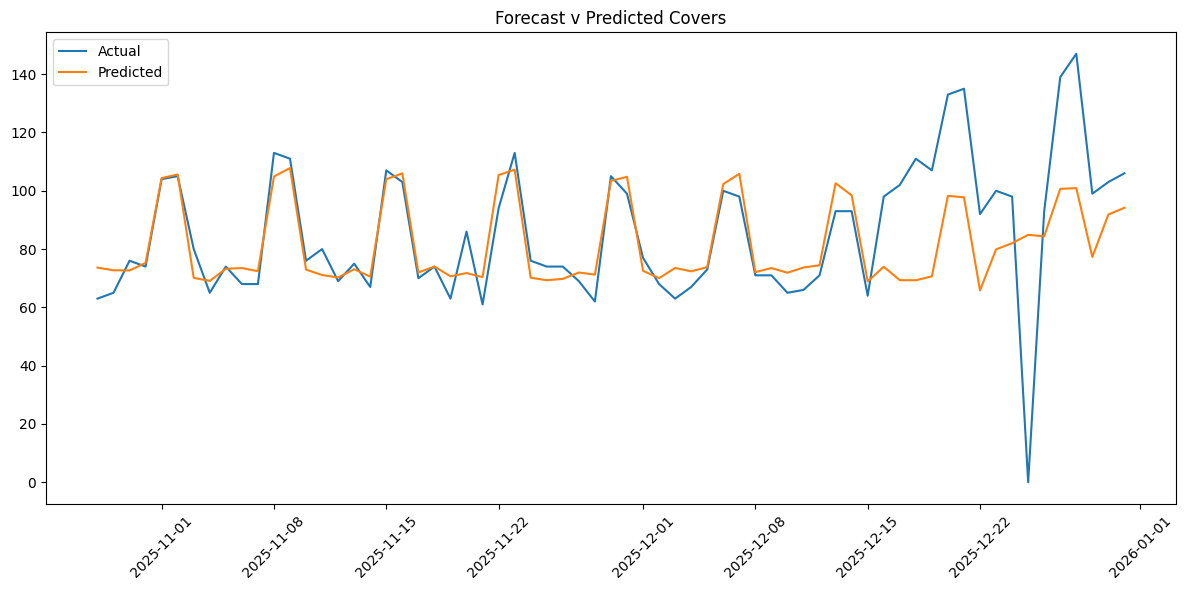

In [ ]:
# --- Forecast v Actual Visualization ---
plt.figure(figsize=(12,6))

plt.plot(test['date'], y_test, label="Actual")
plt.plot(test['date'], rf_preds, label="Predicted")

plt.legend()
plt.title("Forecast v Predicted Covers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

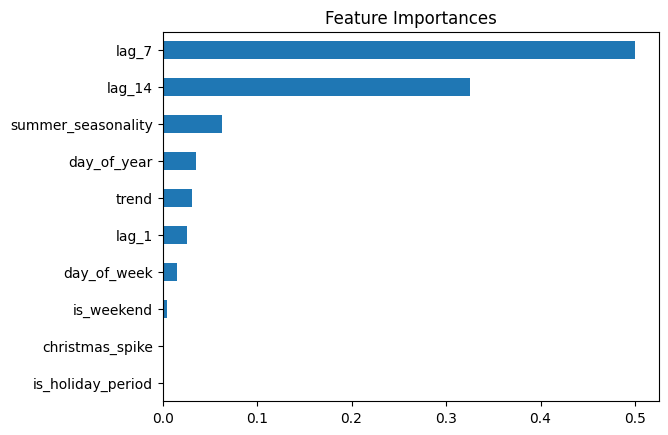

In [ ]:
# --- Feature Importance ---

importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importances')
plt.show()

In [82]:
# --- Baseline model (Naive forecasting) ---

baseline_preds = test['lag_1']

baseline_mae = mean_absolute_error(y_test, baseline_preds)

print("Baseline MAE (Lag-1):", round(baseline_mae, 2))


Baseline MAE (Lag-1): 17.12


In [83]:
# --- Linear Regression model  ---

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_preds = lin_model.predict(X_test)

lin_mae = mean_absolute_error(y_test, lin_preds)

print("Linear Regression MAE:", round(lin_mae, 2))


Linear Regression MAE: 12.4


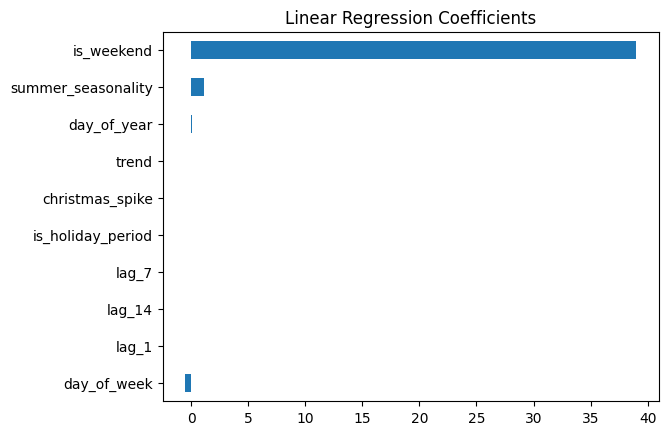

In [ ]:
# --- Linear Regession coefficients ---
coef_df = pd.Series(lin_model.coef_, index=features)
coef_df.sort_values().plot(kind='barh')
plt.title("Linear Regression Coefficients")
plt.show()


In [84]:
# --- Model comparison ---

print("\nModel Comparison:")
print("-------------------")
print("Baseline MAE:", round(baseline_mae, 2))
print("Linear Regression MAE:", round(lin_mae, 2))
print("Random Forest MAE:", round(mae, 2))


Model Comparison:
-------------------
Baseline MAE: 17.12
Linear Regression MAE: 12.4
Random Forest MAE: 11.32


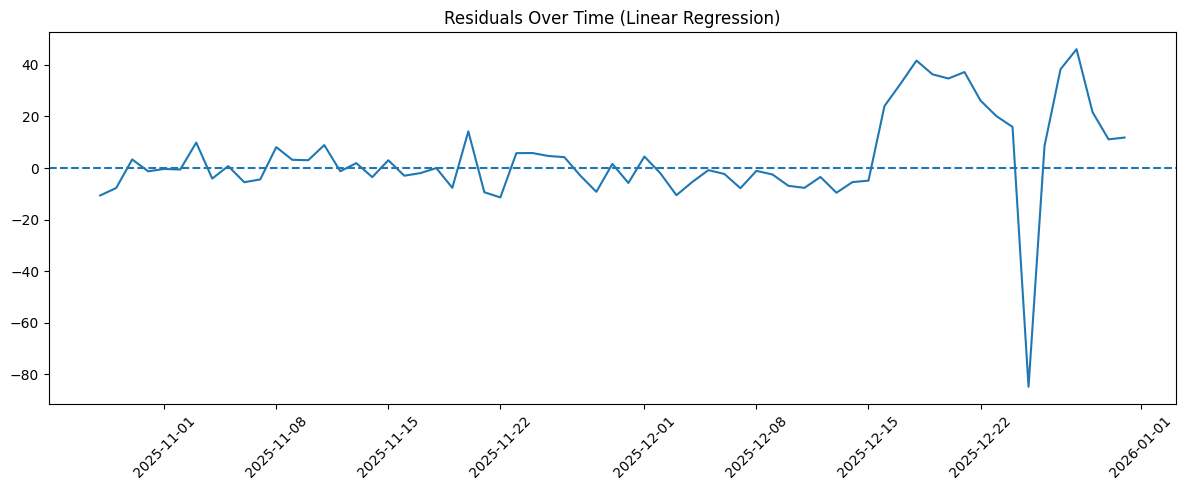

In [ ]:
# --- Residual Analysis (Random Forest Regressor) ---

rf_residuals = y_test - rf_preds

plt.figure(figsize=(12,5))
plt.plot(test['date'], rf_residuals)
plt.axhline(0, linestyle='--')
plt.title("Residuals Over Time (Random Forest Regression)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
"""
I've evaluated three forecasting approaches here:
    - Naive basline (lag-1)
    - Random Forest Regressor
    - Linear Regression

I compared MAE's of each and given the available information
and nature of the problem it makes sense to continue with
the Random Forest REgressor model for the purposes of this
project


From a business point of view, the model provides
stable and interpretable forecasts that are suitable
for short-term operational planning.
"""

"\nI've evaluated three forecasting approaches here:\n    - Naive basline (lag-1)\n    - Random Forest Regressor\n    - Linear Regression\n\nLinear Regression achieved the lowest MAE, showing\nthat the demand pattern in the dataset are largely\nlinear once lag and calendar features are taken into \naccount.\n\nResidual analysis shows forecasting errors increase \nduring the busy Xmas period, due to limited historical\nexposure.\n\nFrom a business point of view, the model provides\nstable and interpretable forecasts that are suitable\nfor short-term operational planning.\n"

In [100]:
# --- Retrain model using full dataset ---

rf_final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

X_full = covers[features]
y_full = covers['covers']

rf_final_model.fit(X_full, y_full)

print("Final Random Forest model trained on full 2025 data")

Final Random Forest model trained on full 2025 data


In [101]:
# --- Forecast covers for 2026 (Random Forest) ---

forecast_df = covers.copy()

# Generate future dates (2026)
future_dates = pd.date_range(start=forecast_df['date'].max() + pd.Timedelta(days=1), periods=365)
future = pd.DataFrame({'date': future_dates})
forecast_df = pd.concat([forecast_df, future], ignore_index=True)

# Recreate all non-lag features
forecast_df['day_of_week'] = forecast_df['date'].dt.dayofweek
forecast_df['is_weekend'] = forecast_df['day_of_week'].isin([5, 6]).astype(int)
forecast_df['day_of_year'] = forecast_df['date'].dt.dayofyear

# Xmas spike
forecast_df['christmas_spike'] = 0

forecast_df.loc[
    (forecast_df['date'].dt.month == 12) &
    (forecast_df['date'].dt.day >= 20),
    'christmas_spike'
] = 60

# Extend trend forward smoothly
forecast_df['trend'] = np.linspace(
    0,
    covers['trend'].max() + 10,
    len(forecast_df)
)

# Summer seasonality (same formula as simulation)
forecast_df['summer_seasonality'] = 35 * np.exp(
    -((forecast_df['day_of_year'] - 200) ** 2) /
    (2 * 40 ** 2)
)

# Holiday period flag (2026)
holiday_dates_2026 = pd.to_datetime([
    "2026-01-01",
    "2026-01-06",
    "2026-12-20", "2026-12-21", "2026-12-22", "2026-12-23",
    "2026-12-24", "2026-12-25", "2026-12-26", "2026-12-27",
    "2026-12-28", "2026-12-29", "2026-12-30", "2026-12-31"
])

forecast_df['is_holiday_period'] = forecast_df['date'].isin(holiday_dates_2026).astype(int)

# 3️⃣ Prepare covers column for recursion
# --------------------------------------------------

forecast_df.loc[len(covers):, 'covers'] = np.nan
historical_mean = covers['covers'].mean()


# 4️⃣ Recursive Forecast Loop
# --------------------------------------------------

for i in range(len(covers), len(forecast_df)):

    forecast_df.loc[i, 'lag_1']  = forecast_df.loc[i-1, 'covers']
    forecast_df.loc[i, 'lag_7']  = forecast_df.loc[i-7, 'covers']  if i-7 >= 0 else historical_mean
    forecast_df.loc[i, 'lag_14'] = forecast_df.loc[i-14, 'covers'] if i-14 >= 0 else historical_mean

    row = forecast_df.loc[i, features].to_frame().T
    forecast_df.loc[i, 'covers'] = rf_final_model.predict(row)[0]

# 5️⃣ Extract 2026 Forecast
# --------------------------------------------------

forecast_2026 = forecast_df[forecast_df['date'].dt.year == 2026]

print(forecast_2026['covers'].describe())

print("Actual Covers 2025:", round(covers['covers'].sum()))
print("Forecasted Total Covers 2026:", round(forecast_2026['covers'].sum(), 2))
print("Forecasted Average Covers 2026:", round(forecast_2026['covers'].mean(), 2))

count    365.000000
mean     102.082767
std       12.274748
min       69.560000
25%       97.010000
50%       99.045000
75%      107.695000
max      140.840000
Name: covers, dtype: float64
Actual Covers 2025: 30283
Forecasted Total Covers 2026: 37260.21
Forecasted Average Covers 2026: 102.08


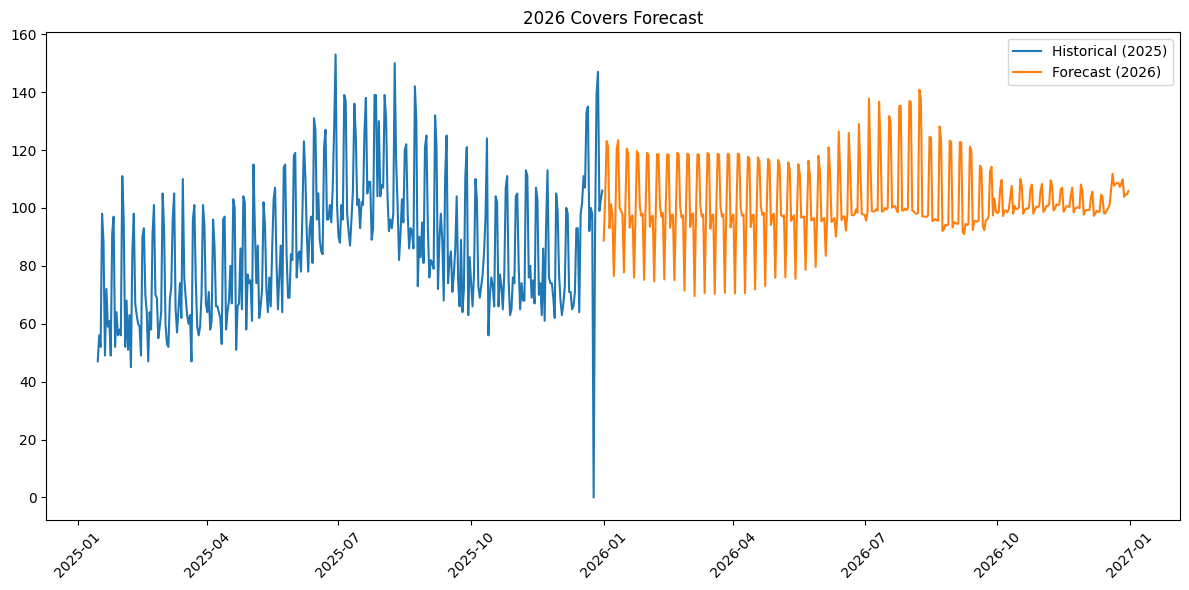

In [102]:
# --- Plot 2025 v 2026 ---

plt.figure(figsize=(12,6))

# Plot last years actuals
plt.plot(covers['date'], covers['covers'], label="Historical (2025)")

# Plot forecast 
plt.plot(forecast_2026['date'], forecast_2026['covers'], label="Forecast (2026)")

plt.legend()
plt.title("2026 Covers Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

              feature  importance
0               lag_7    0.396834
1              lag_14    0.378139
6  summer_seasonality    0.068811
8               trend    0.053046
4         day_of_year    0.052788
2         day_of_week    0.026968
7     christmas_spike    0.010950
3          is_weekend    0.009075
5   is_holiday_period    0.003391


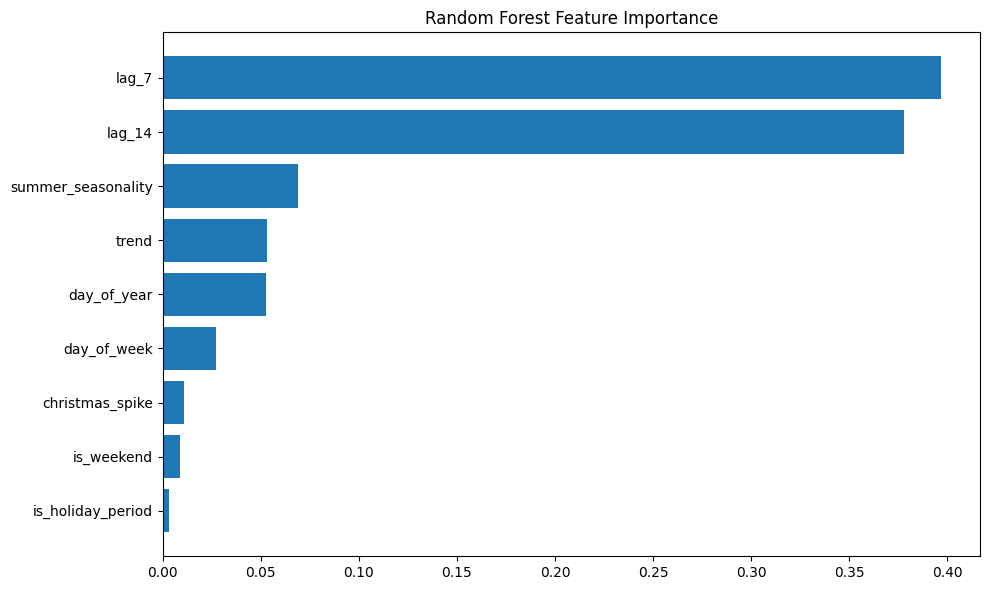

In [104]:
# --- Fully trained model feature importance ---

importances = rf_final_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(importance_df)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [98]:
forecast_2026[['date','covers','trend']].head(10)

,date,covers,trend
351,2026-01-01,91.065,9.818182
352,2026-01-02,101.830,9.846154
353,2026-01-03,123.660,9.874126
354,2026-01-04,122.980,9.902098
355,2026-01-05,94.430,9.930070
356,2026-01-06,100.825,9.958042
357,2026-01-07,98.925,9.986014
358,2026-01-08,75.940,10.013986
359,2026-01-09,94.335,10.041958
360,2026-01-10,120.715,10.069930
